In [1]:
# =============================================================================
# Antibiotic Resistance Prediction using Proximity, Frequency, and G-score
# =============================================================================
# 
# This notebook trains and evaluates Random Forest classifiers on mutation-level
# features (mutation frequency, 3D structural proximity to known resistance-conferring
# mutations, and g-scores) to predict antibiotic resistance in Mycobacterium tuberculosis.
# It includes baseline modeling,combined modeling and predictions for uncertain mutations (Category 3).

In [1]:
## load dependencies
import pandas as pd
import numpy as np
import re
from evcouplings.compare import DistanceMap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score,roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay)
from scipy import stats
import os,json

In [2]:
from utils import *

## data preprocessing

In [3]:
# ----------------------------
# STEP 1: Load and Inspect Dataset
# ----------------------------
final_df = pd.read_csv("../data/derived_features/all_proteins_freq_proximity_gscore.csv")
print("Unique genes:", np.unique(final_df['gene']))
print("Data shape:", final_df.shape)

Unique genes: ['Rv0678' 'atpE' 'ddn' 'embB' 'ethA' 'fgd1' 'gid' 'gyrA' 'gyrB' 'inhA'
 'katG' 'pepQ' 'pncA' 'rplC' 'rpoB' 'rpsL' 'tlyA']
Data shape: (4690, 12)


In [4]:
# STEP 2: Basic Preprocessing
# ----------------------------
# Separate Category 3 entries (uncertain mutations)
category_3_data = final_df[final_df['confidence'] == "3) Uncertain significance"]

# Retain only labeled data (non-Category 3) for supervised learning
label_data = final_df[final_df['confidence'] != "3) Uncertain significance"]

# Target conversion to binary
label_data['binary_confidence'] = label_data['confidence'].map({
    "1) Assoc w R": 0,
    "2) Assoc w R - Interim": 0,
    "4) Not assoc w R - Interim": 1,
    "5) Not assoc w R": 1
})

# Drop missing targets
label_data = label_data[label_data['binary_confidence'].notna()]

#some debugging steps
print(label_data['confidence'].value_counts())
print(np.unique(label_data['confidence']))
# Identify rows where the 'frequency' column is NaN
nan_frequency_rows = label_data[label_data['frequency'].isna()]

diverse_sample_mutation_table = label_data.groupby('frequency').first().reset_index()
diverse_sample_mutation_table.head()

confidence
2) Assoc w R - Interim        160
1) Assoc w R                  155
5) Not assoc w R               38
4) Not assoc w R - Interim     22
Name: count, dtype: int64
['1) Assoc w R' '2) Assoc w R - Interim' '4) Not assoc w R - Interim'
 '5) Not assoc w R']


/tmp/ipykernel_2819610/3132060444.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_data['binary_confidence'] = label_data['confidence'].map({


,frequency,drug,gene,variant,confidence,one_letter_mutation,phenotype,position,WHO_Adjusted_Position,Proximity_to_R_Conferring,Nearest_Mutation_Index,G_score,binary_confidence
0,0.000000,RIF,rpoB,rpoB_G426S,2) Assoc w R - Interim,G426S,Resistant,426,432,1.335177,433.0,2.296259,0
1,0.010204,EMB,embB,embB_Q139H,5) Not assoc w R,Q139H,Susceptible,139,145,15.434290,80.0,-0.302846,1
2,0.013274,LEV,gyrB,gyrB_P94L,5) Not assoc w R,P94L,Susceptible,94,100,44.316136,505.0,-1.423563,1
3,0.018182,RIF,rpoB,rpoB_K944E,5) Not assoc w R,K944E,Susceptible,944,950,44.237799,449.0,-0.120555,1
4,0.020609,MXF,gyrA,gyrA_A384V,5) Not assoc w R,A384V,Susceptible,384,390,41.360897,96.0,-0.177343,1


## run the baseline and combined models

In [5]:
feature_sets = {
    "Frequency": ['frequency'],
    "Proximity": ['Proximity_to_R_Conferring'],
    "G-score": ['G_score'],
    "Frequency + Proximity": ['frequency', 'Proximity_to_R_Conferring'],
    "Frequency + G-score": ['frequency', 'G_score'],
    "Combined": ['frequency', 'Proximity_to_R_Conferring', 'G_score']
}



=== Running model for: Frequency ===
Confusion Matrix:
[[88  7]
 [ 0 18]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        95
           1       0.72      1.00      0.84        18

    accuracy                           0.94       113
   macro avg       0.86      0.96      0.90       113
weighted avg       0.96      0.94      0.94       113



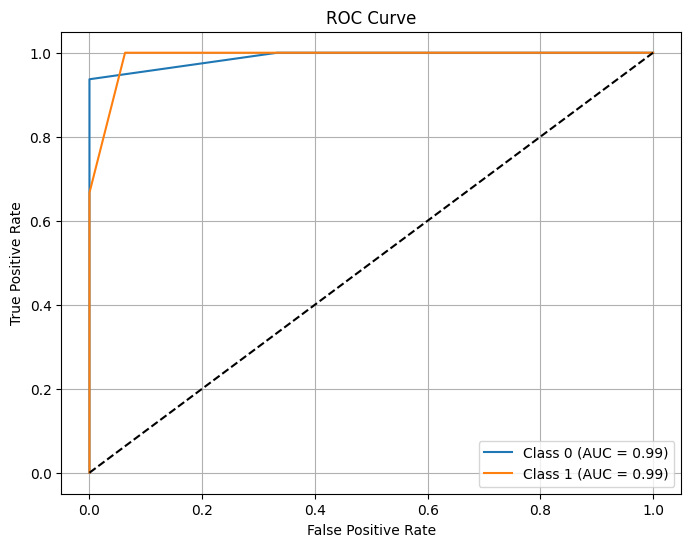

Accuracy: 0.9380530973451328
AUC: {0: 0.9894736842105264, 1: 0.9894736842105263}
Precision: 0.9553982300884956


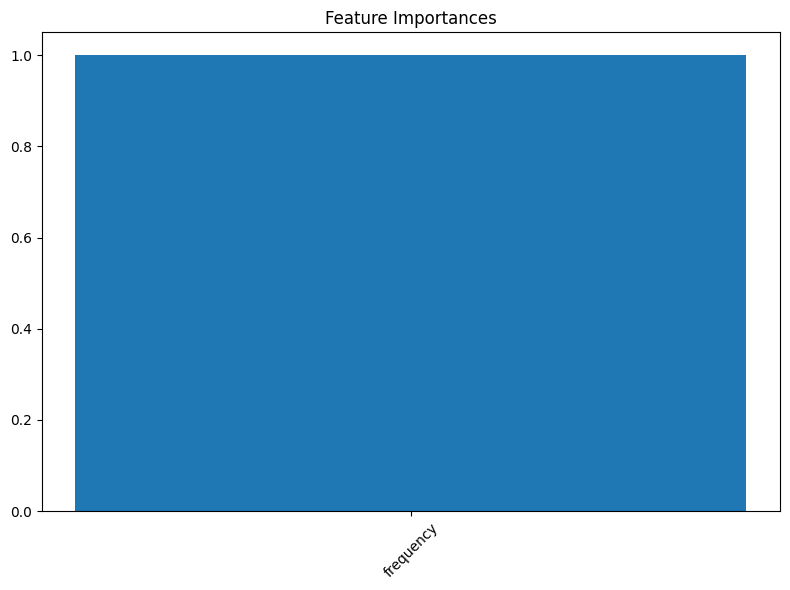


=== Running model for: Proximity ===
Confusion Matrix:
[[93  2]
 [ 8 10]]
Classification Report:


/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        95
           1       0.83      0.56      0.67        18

    accuracy                           0.91       113
   macro avg       0.88      0.77      0.81       113
weighted avg       0.91      0.91      0.90       113



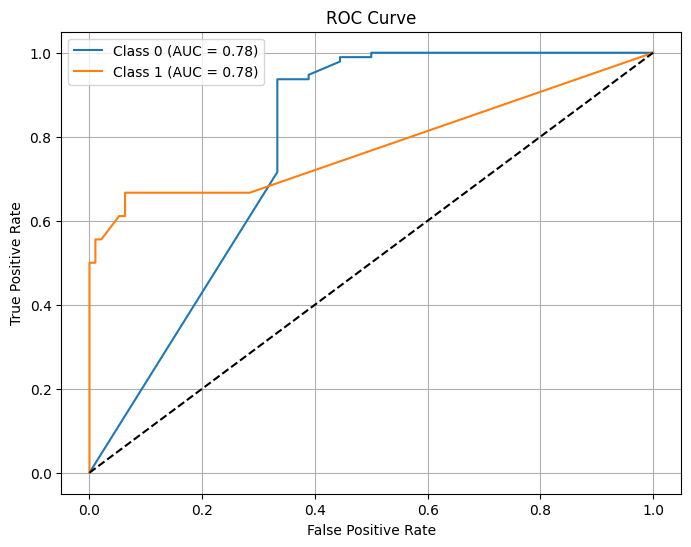

Accuracy: 0.911504424778761
AUC: {0: 0.7798245614035088, 1: 0.7798245614035088}
Precision: 0.9068605975641812


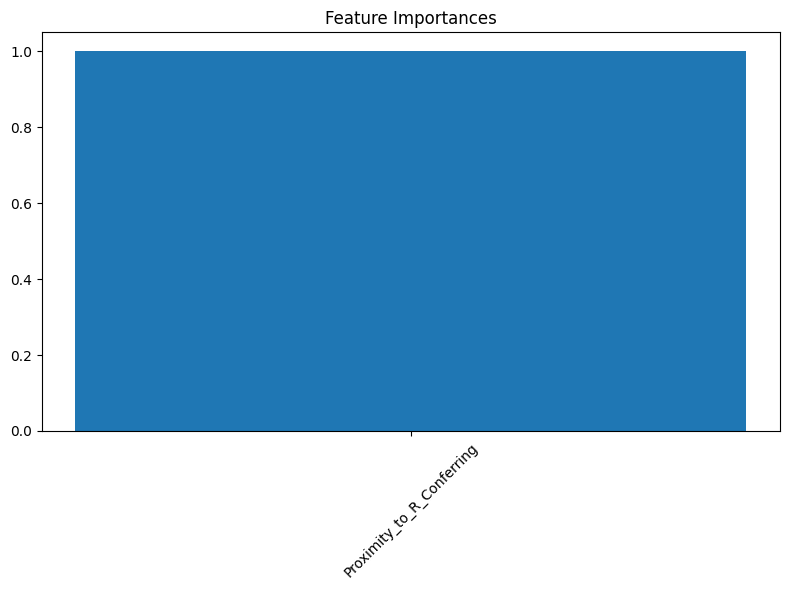


=== Running model for: G-score ===
Confusion Matrix:
[[87  8]
 [ 3 15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        95
           1       0.65      0.83      0.73        18

    accuracy                           0.90       113
   macro avg       0.81      0.87      0.84       113
weighted avg       0.92      0.90      0.91       113



/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

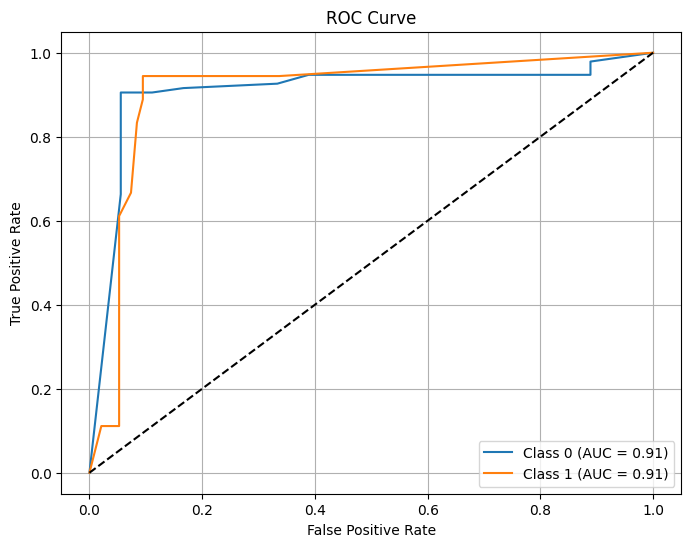

Accuracy: 0.9026548672566371
AUC: {0: 0.9084795321637427, 1: 0.9084795321637427}
Precision: 0.9165704758240348


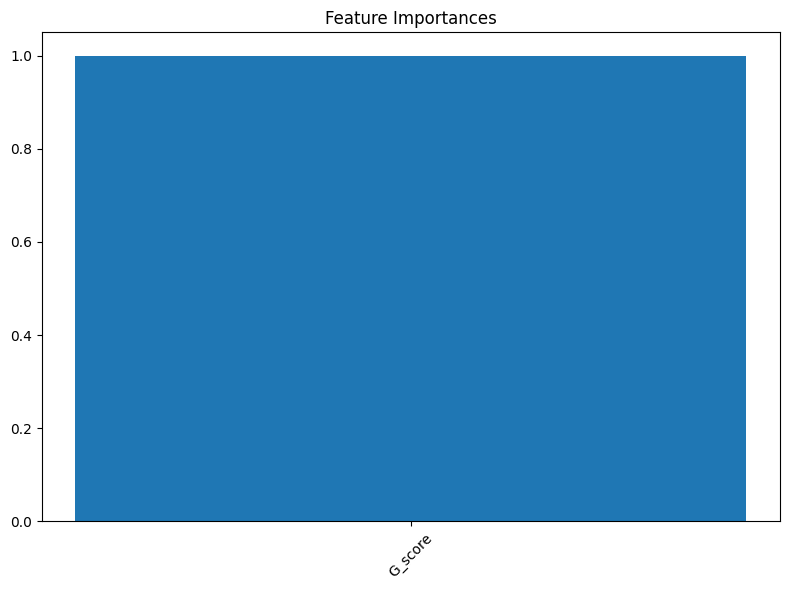


=== Running model for: Frequency + Proximity ===
Confusion Matrix:
[[91  4]
 [ 1 17]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        95
           1       0.81      0.94      0.87        18

    accuracy                           0.96       113
   macro avg       0.90      0.95      0.92       113
weighted avg       0.96      0.96      0.96       113



/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

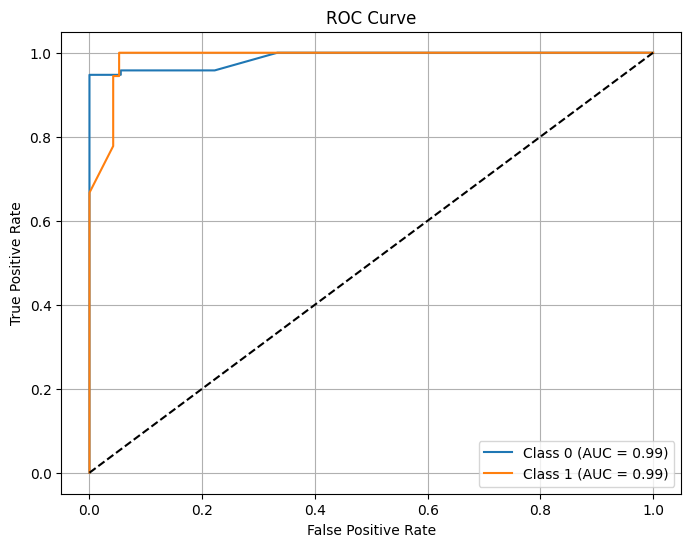

Accuracy: 0.9557522123893806
AUC: {0: 0.9877192982456141, 1: 0.987719298245614}
Precision: 0.9605205298741274


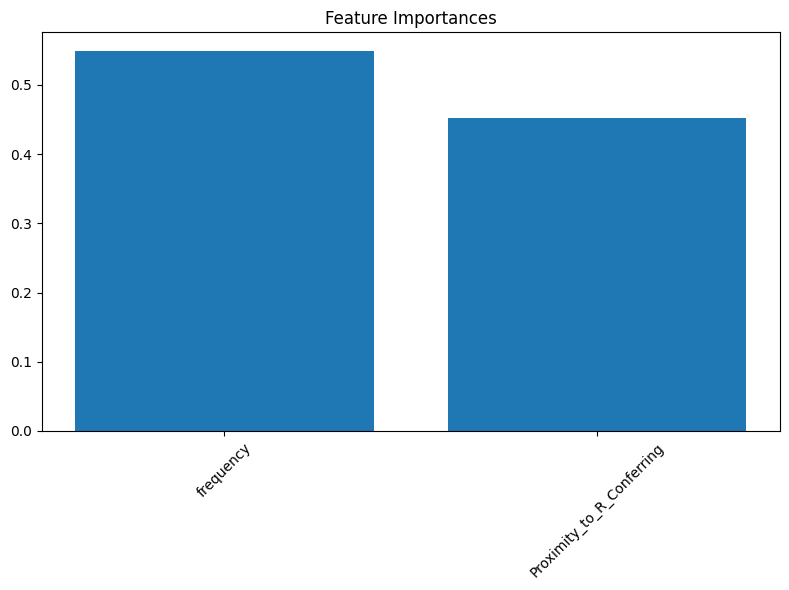


=== Running model for: Frequency + G-score ===
Confusion Matrix:
[[93  2]
 [ 0 18]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        95
           1       0.90      1.00      0.95        18

    accuracy                           0.98       113
   macro avg       0.95      0.99      0.97       113
weighted avg       0.98      0.98      0.98       113



/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

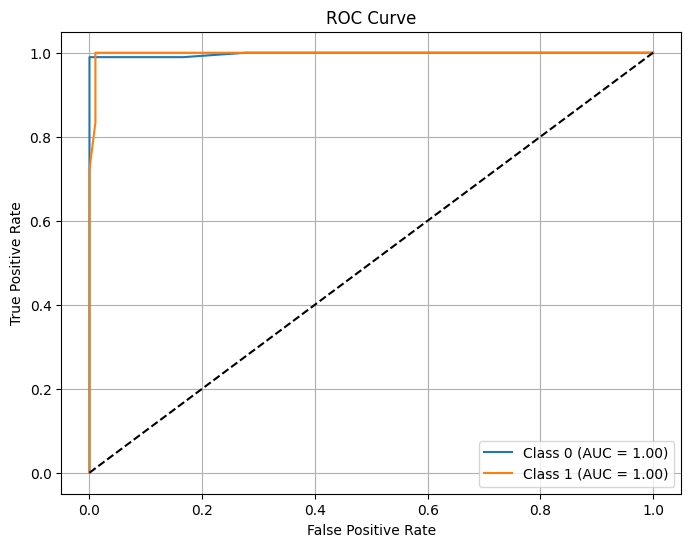

Accuracy: 0.9823008849557522
AUC: {0: 0.9976608187134504, 1: 0.9976608187134502}
Precision: 0.984070796460177


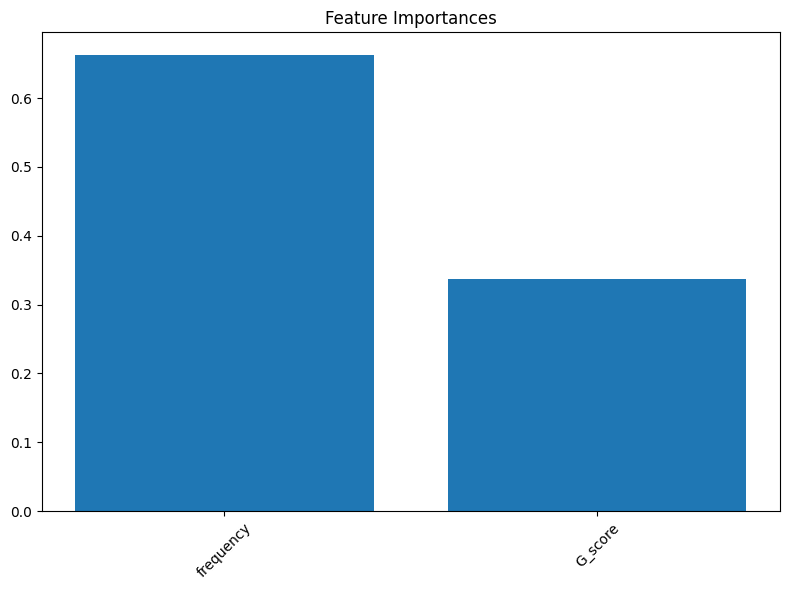


=== Running model for: Combined ===
Confusion Matrix:
[[94  1]
 [ 0 18]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        95
           1       0.95      1.00      0.97        18

    accuracy                           0.99       113
   macro avg       0.97      0.99      0.98       113
weighted avg       0.99      0.99      0.99       113



/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

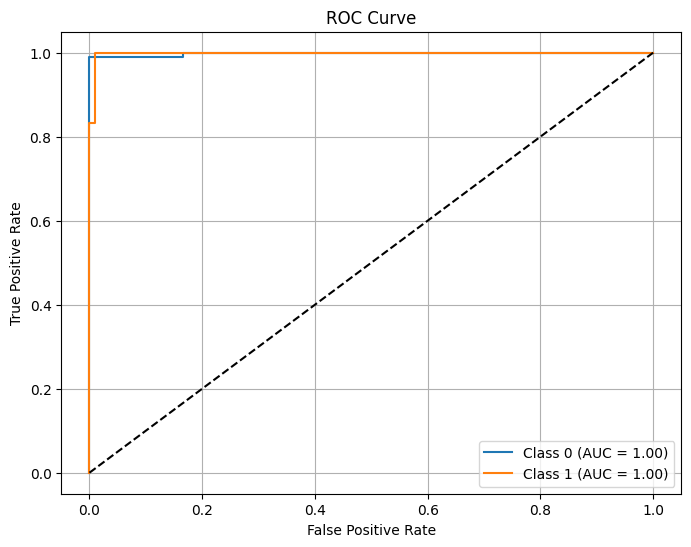

Accuracy: 0.9911504424778761
AUC: {0: 0.9982456140350877, 1: 0.9982456140350877}
Precision: 0.9916162086632511


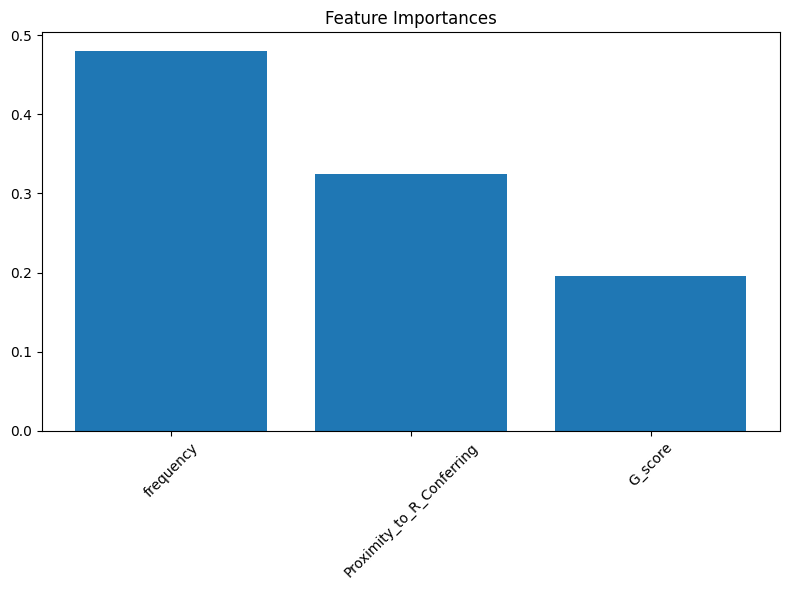

/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  category_3_data[numeric_columns] = category_3_data[numeric_columns].fillna(0)
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/work/pi_annagreen_umass_edu/mahbuba/MTB_Mut_Clust/scripts/utils.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

In [6]:
results = {}

for label, numeric_columns in feature_sets.items():
    print(f"\n=== Running model for: {label} ===")

    # Step 3: Feature selection
    label_data[numeric_columns] = label_data[numeric_columns].fillna(0)
    
    # Step 4: Split
    X_train, X_test, y_train, y_test, train_indices, test_indices = data_split(label_data, numeric_columns)
    
    # Step 5: Train and evaluate
    trained_rf, y_pred_test, y_prob_test = model_training(X_train, y_train, X_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    accuracy, roc_auc, precision = performance_evaluation(y_test, y_pred_test, y_prob_test)
    print("Accuracy:", accuracy)
    print("AUC:", roc_auc)
    print("Precision:", precision)

    # Step 6: Feature importance
    feature_importances = plot_feature_importance(trained_rf, numeric_columns)

    # Step 7: Category 3 prediction
    (
        misclassified_original_indices,
        misclassified_samples,
        confidence_0_count,
        confidence_0_percentage,
        confidence_1_count,
        confidence_1_percentage
    ) = predict_category_3(
        category_3_data,
        trained_rf,
        final_df,
        numeric_columns,
        y_test,
        y_pred_test,
        test_indices
    )

    # Store all results
    results[label] = {
        "features": numeric_columns,
        "accuracy": accuracy,
        "precision": precision,
        "roc_auc": roc_auc,
        "feature_importance": feature_importances,
        "misclassified_indices": misclassified_original_indices,
        "misclassified_samples": misclassified_samples,
        "category_3_predictions": {
            "resistant_count": confidence_0_count,
            "susceptible_count": confidence_1_count,
            "resistant_percentage": confidence_0_percentage,
            "susceptible_percentage": confidence_1_percentage
        }
    }


In [7]:
def find_invalid_keys(obj, path="root"):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if not isinstance(k, (str, int, float, bool, type(None))):
                print(f"[Invalid Key] Path: {path} → Key: {k} (type: {type(k).__name__})")
            find_invalid_keys(v, path=f"{path}['{k}']")
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            find_invalid_keys(item, path=f"{path}[{i}]")


# Check before saving
find_invalid_keys(results)

def convert_keys_to_str(obj):
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str(i) for i in obj]
    else:
        return obj
cleaned_results = convert_keys_to_str(results)

[Invalid Key] Path: root['Frequency']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Frequency']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['Proximity']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Proximity']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['G-score']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['G-score']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['Frequency + Proximity']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Frequency + Proximity']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['Frequency + G-score']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Frequency + G-score']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['Combined']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Combined']['roc_auc'] → Key: 1 (type: int64)


In [9]:
with open("../results/baseline_combined_results.json", "w") as f:
    for label in cleaned_results:
        for key in cleaned_results[label]:
            if not isinstance(key, (str, int, float, bool, type(None))):
                print("Invalid key type:", key, type(key))
    json.dump(cleaned_results, f, indent=4, default=str)

print("\nAll model combinations evaluated and saved.")


All model combinations evaluated and saved.


In [10]:
def generate_markdown_table(results_dict):
    table_md = "| Model | Accuracy | AUC (avg) | Precision |\n"
    table_md += "|--------|----------|------------|-----------|\n"

    for model_name, metrics in results_dict.items():
        acc = f"{metrics.get('accuracy', 0) * 100:.1f}%"
        prec = f"{metrics.get('precision', 0) * 100:.1f}%"

        roc_auc = metrics.get('roc_auc', None)
        if isinstance(roc_auc, dict):
            # Average over classes
            auc_val = np.mean(list(roc_auc.values()))
        else:
            auc_val = roc_auc

        auc_str = f"{auc_val * 100:.1f}%" if auc_val is not None else "N/A"

        table_md += f"| {model_name} | {acc} | {auc_str} | {prec} |\n"

    return table_md


In [11]:
markdown_output = generate_markdown_table(cleaned_results)
print(markdown_output)

| Model | Accuracy | AUC (avg) | Precision |
|--------|----------|------------|-----------|
| Frequency | 93.8% | 98.9% | 95.5% |
| Proximity | 91.2% | 78.0% | 90.7% |
| G-score | 90.3% | 90.8% | 91.7% |
| Frequency + Proximity | 95.6% | 98.8% | 96.1% |
| Frequency + G-score | 98.2% | 99.8% | 98.4% |
| Combined | 99.1% | 99.8% | 99.2% |

